In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


In [2]:
df = pd.read_csv(r"D:\GIT\data-analytics-portfolio\02-telco-customer-churn\data\clean_data\telco_customer_churn_cleaned.csv")

print(df.head())
print(df.info())
print(df.shape)
print(df.describe())

   customerid  gender  seniorcitizen partner dependents  tenure phoneservice  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      multiplelines internetservice onlinesecurity  ... deviceprotection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  techsupport streamingtv streamingmovies        contract pape

The Telco Customer Churn dataset contains 7,043 customer records and 21 variables. Of these, 4 variables are numeric and 17 are categorical. The dataset includes demographic information, service subscriptions, billing details, and the target variable churn. The average customer tenure is 32.37 months, while the average monthly charge is $64.76 and the average total charge is $2,279.73. This mix of numerical and categorical features provides a strong foundation for investigating the factors associated with customer churn.

In [3]:
# Count distribution of churn values

df["churn"].value_counts()

churn
No     5174
Yes    1869
Name: count, dtype: int64

In [4]:
df["churn"].value_counts(normalize=True) * 100

churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

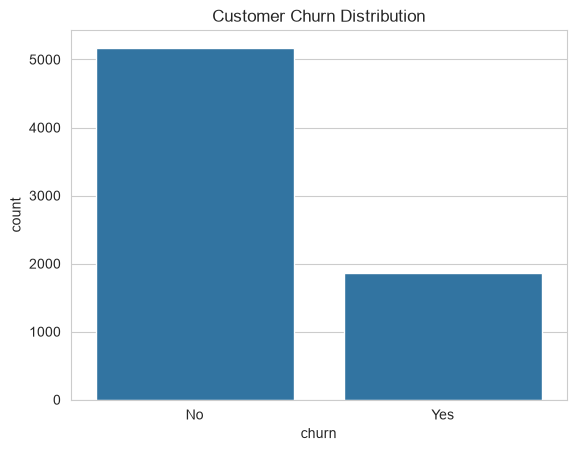

In [5]:
# visualization of churn distribution

sns.countplot(
    data=df,
    x="churn"
)

plt.title("Customer Churn Distribution")
plt.show()

### Insight: Customer Churn Distribution

The churn distribution indicates that the dataset is **imbalanced**, with significantly more customers remaining with the company (`No`) than leaving (`Yes`).

#### Key Observations
- Approximately **73%** of customers did not churn, while about **27%** churned.
- The number of non-churned customers is nearly **three times higher** than the number of churned customers.
- Customer retention appears to be stronger than customer attrition, as the majority of customers remain subscribed.

#### Business Implications
- Although most customers stay, the proportion of churned customers is substantial and represents a significant loss of revenue and customer lifetime value.
- Understanding the characteristics of churned customers should be a priority to identify factors contributing to customer attrition and develop effective retention strategies.

#### Data Science Implications
- The target variable (`churn`) is **class imbalanced**, which may affect model performance.
- Accuracy alone may be misleading during model evaluation because a model could achieve high accuracy by predominantly predicting the majority class.
- Additional evaluation metrics such as **Precision, Recall, F1-Score, and ROC-AUC** should be considered when building churn prediction models.
- Techniques such as class weighting, oversampling (SMOTE), or undersampling may be explored during the modelling phase if imbalance negatively impacts predictive performance.

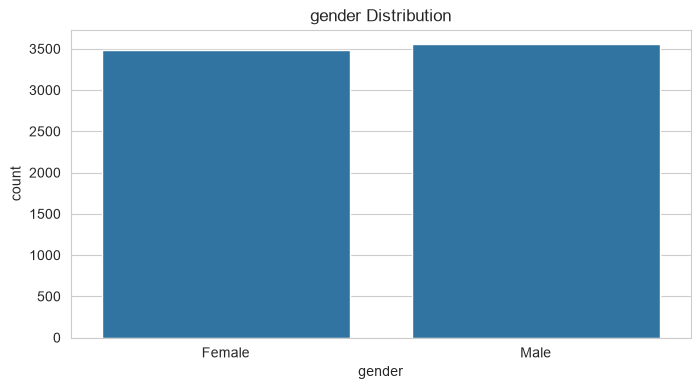

In [7]:
# function to plot count distribution of a column
def plot_count(df, column):

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=column
    )

    plt.title(f"{column} Distribution")

    plt.show()

plot_count(df, "gender")

In [8]:
numerical_columns = [
    "tenure",
    "monthlycharges",
    "totalcharges"
]

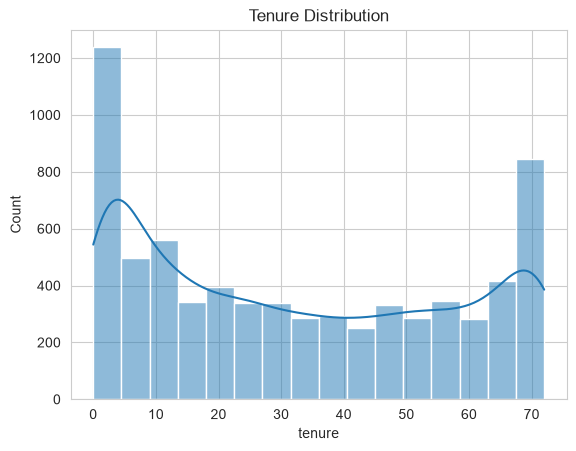

In [9]:
# tenure distribution

sns.histplot(
    df["tenure"],
    kde=True
)

plt.title("Tenure Distribution")
plt.show()

In [10]:
df["tenure"].describe()

count    7043.000000
mean       32.371149
std        24.559481
min         0.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: tenure, dtype: float64

## Tenure Distribution Summary

The dataset contains **7,043 customers** with tenure values ranging from **0 to 72 months**. The average customer tenure is **32.37 months**, while the median tenure is **29 months**, indicating that half of the customers have been with the company for less than 29 months.


### Distribution Insights
- The tenure distribution exhibits a **U-shaped (bimodal) pattern**, with large concentrations of customers at both the beginning and end of the tenure range.
- A significant number of customers have **very low tenure (0–5 months)**, suggesting a strong influx of new customers.
- Another substantial group has **high tenure (65–72 months)**, indicating a loyal and long-standing customer base.
- The middle tenure ranges contain fewer customers, creating a noticeable dip in the distribution.

### Business Implications
- The presence of many new customers highlights the importance of **early-stage retention strategies**.
- The large group of long-tenured customers suggests successful long-term customer retention.
- Tenure is likely to be an important variable for predicting customer behavior, particularly **customer churn and loyalty**.
- Further analysis could identify factors that help customers transition from new subscribers to long-term loyal customers.

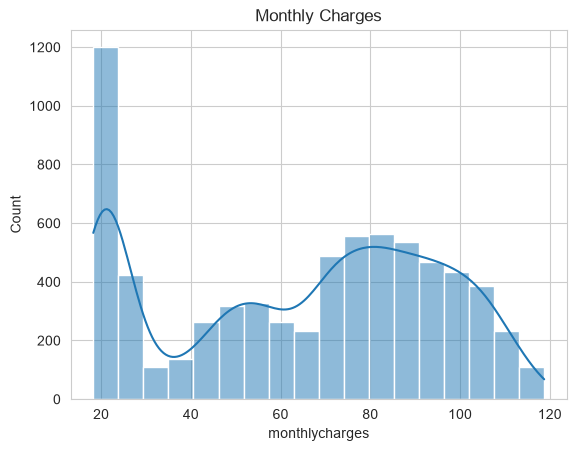

In [11]:
# monthly charges distribution

sns.histplot(
    df["monthlycharges"],
    kde=True
)

plt.title("Monthly Charges")
plt.show()


### Insight: Monthly Charges Distribution

The distribution of monthly charges appears to be **bimodal**, with two prominent customer groups: one concentrated at lower monthly charges (approximately $20-$30) and another spread across higher monthly charges (approximately $70-$100).

#### Key Observations
- A large proportion of customers pay relatively low monthly charges, creating a noticeable peak around the $20-$30 range.
- A second concentration of customers exists in the higher pricing tiers between $70 and $100.
- The distribution is not normally distributed, suggesting the presence of distinct customer segments with different service packages.
- Monthly charges range from approximately $18 to $120, indicating considerable variation in subscription plans and services.

#### Business Implications
- The lower-charge segment may represent customers with basic service packages or limited bundled services.
- The higher-charge segment likely corresponds to customers subscribed to premium services, additional features, or bundled offerings.
- Further analysis should investigate whether customers with higher monthly charges exhibit different churn behavior compared to lower-paying customers.


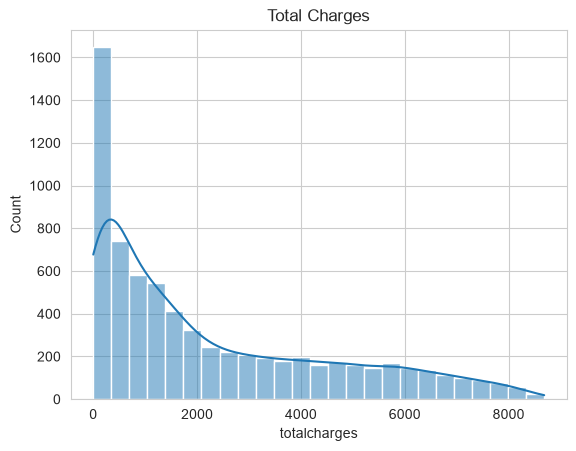

In [12]:
# Total charges distribution

sns.histplot(
    df["totalcharges"],
    kde=True
)

plt.title("Total Charges")
plt.show()


### Insight: Total Charges Distribution

The distribution of total charges is **strongly right-skewed**, with most customers having relatively low cumulative charges and a smaller number of customers accumulating very high total charges.

#### Key Observations
- A large concentration of customers falls within the lower total charges range.
- The frequency of customers gradually decreases as total charges increase.
- A long tail extends to approximately $8,500, indicating a smaller group of customers with substantial cumulative spending.
- The distribution is not symmetric and exhibits significant positive skewness.

#### Business Implications
- Customers with lower total charges are likely newer customers with shorter tenure.
- Customers with higher total charges are likely long-term customers who have remained with the company for several years.
- The strong relationship between tenure and total charges should be investigated, as longer customer relationships naturally lead to higher cumulative spending.

#### Data Quality Observations
- No obvious data-entry errors are visible from the distribution.
- High total charge values appear to be legitimate observations rather than anomalies, suggesting that outliers should be retained for further analysis.



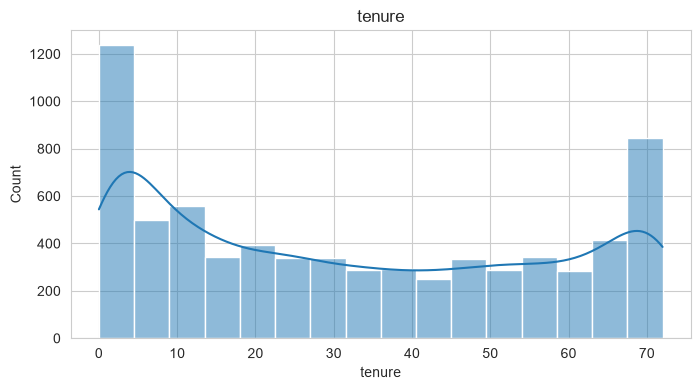

In [13]:
# histogram function.

def plot_histogram(df, column):

    plt.figure(figsize=(8,4))

    sns.histplot(
        df[column],
        kde=True
    )

    plt.title(column)

    plt.show()

plot_histogram(df, "tenure")

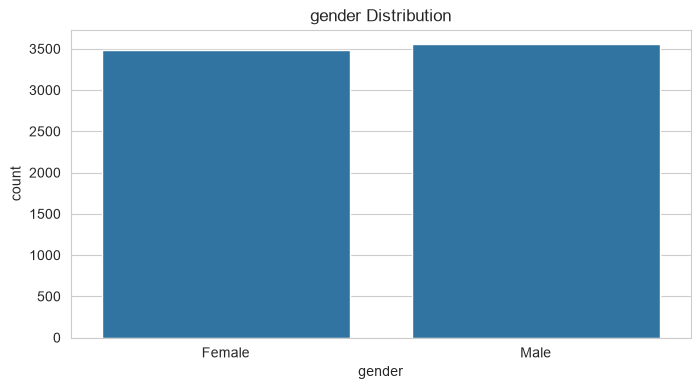

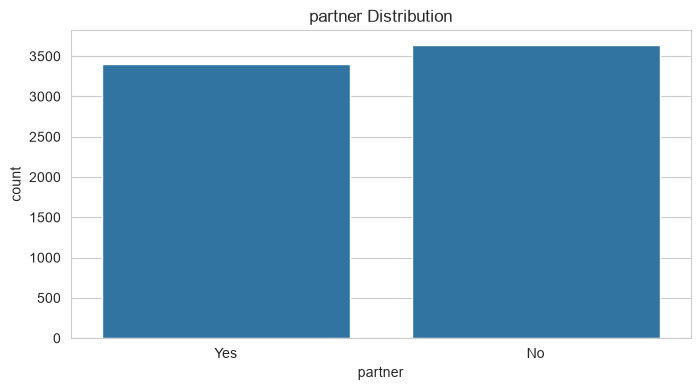

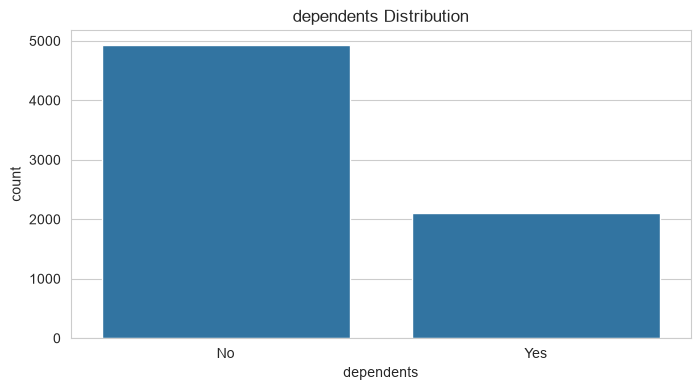

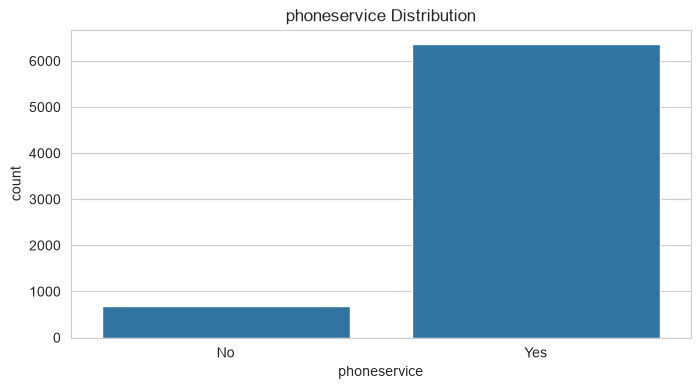

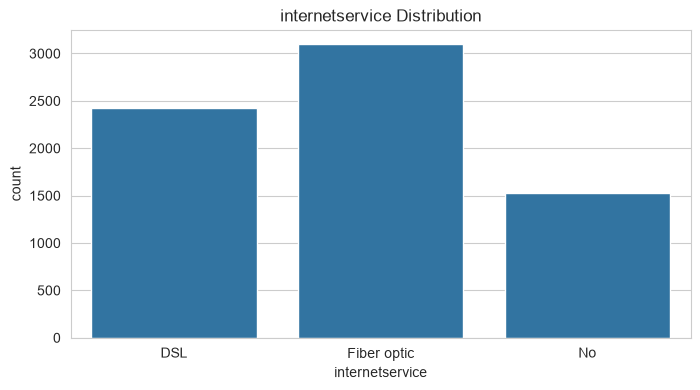

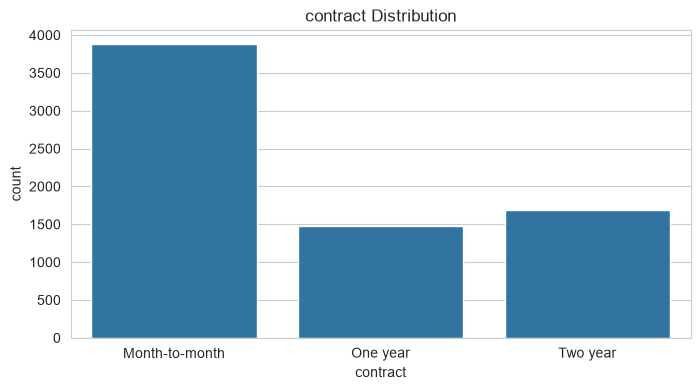

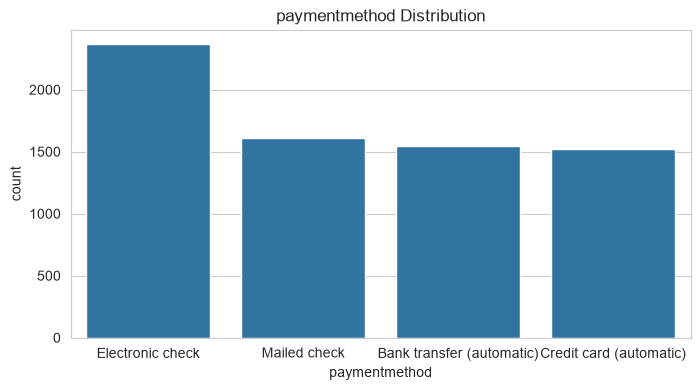

In [14]:
# categorical analysis

categorical_columns = [
    "gender",
    "partner",
    "dependents",
    "phoneservice",
    "internetservice",
    "contract",
    "paymentmethod"
]
for col in categorical_columns:
    plot_count(df, col)


In [15]:
for col in categorical_columns:

    print(f"\n### {col}")

    display(
        pd.DataFrame({
            "Count": df[col].value_counts(),
            "Percentage (%)": round(
                df[col].value_counts(normalize=True) * 100,
                2
            )
        })
    )


### gender


,Count,Percentage (%)
gender,,
Male,3555,50.48
Female,3488,49.52



### partner


,Count,Percentage (%)
partner,,
No,3641,51.7
Yes,3402,48.3



### dependents


...

,Count,Percentage (%)
internetservice,,
Fiber optic,3096,43.96
DSL,2421,34.37
No,1526,21.67



### contract


,Count,Percentage (%)
contract,,
Month-to-month,3875,55.02
Two year,1695,24.07
One year,1473,20.91



### paymentmethod


,Count,Percentage (%)
paymentmethod,,
Electronic check,2365,33.58
Mailed check,1612,22.89
Bank transfer (automatic),1544,21.92
Credit card (automatic),1522,21.61


####  Gender Distribution

The customer base is evenly split between males (50.48%) and females (49.52%). This suggests that gender is unlikely to be a distinguishing characteristic of the overall customer population.

#### Partner Status Distribution

Customers with partners (48.3%) and without partners (51.7%) are almost equally represented. This indicates a balanced distribution of relationship status across the customer base.

#### Dependents Distribution

Most customers (70.04%) do not have dependents, while only 29.96% have dependents. This suggests the customer base is primarily composed of individuals without dependent family members.

#### Phone Service Distribution

Phone service adoption is very high, with 90.32% of customers subscribing to the service. Only a small minority (9.68%) do not use phone services.

#### Contract Type Distribution

Month-to-month contracts are the most common (55.02%), accounting for more than half of all customers. Longer-term contracts are less prevalent, with one-year and two-year contracts representing 20.91% and 24.07% respectively.

#### Payment Method Distribution

Electronic check is the most frequently used payment method (33.58%), while the remaining payment methods are relatively evenly distributed, each accounting for approximately 22% of customers.

#### Internet Service Distribution

Fiber optic is the most popular internet service, accounting for 43.96% of customers, followed by DSL at 34.37%. Approximately 21.67% of customers do not subscribe to any internet service, indicating that internet connectivity is a key component of the company's offerings.

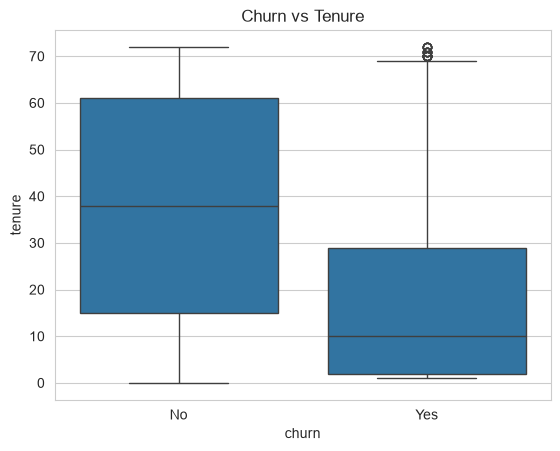

In [16]:
# Churn vs Tenure
sns.boxplot(
    data=df,
    x="churn",
    y="tenure"
)

plt.title(
    "Churn vs Tenure"
)

plt.show()




Customers who churn tend to have significantly shorter tenure than those who stay. This suggests that newer customers are more likely to leave, while long-term customers show higher retention rates.

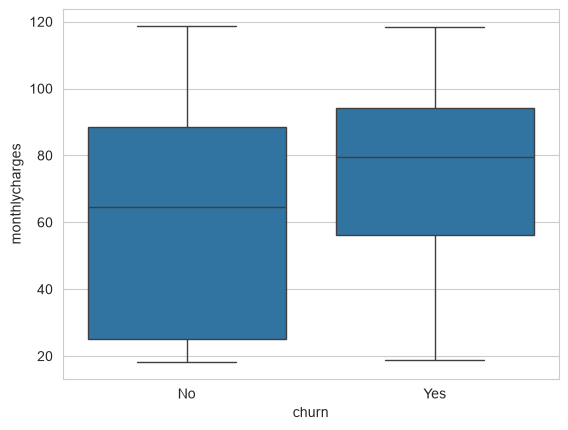

In [17]:
# churn vs Monthly Charges

sns.boxplot(
    data=df,
    x="churn",
    y="monthlycharges"
)

plt.show()




Customers who churn generally have higher monthly charges than those who stay. This suggests that higher-priced plans may be associated with an increased likelihood of churn.

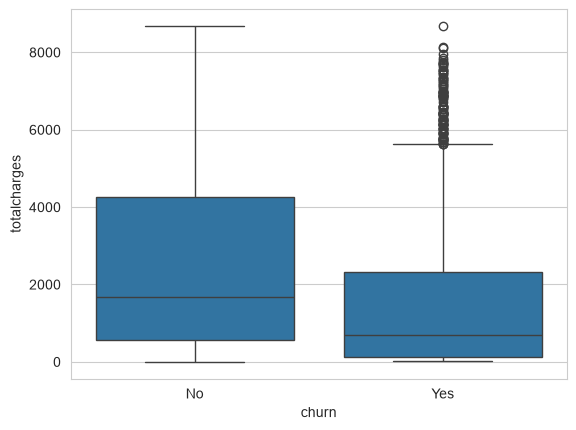

In [18]:
# churn vs Total Charges

sns.boxplot(
    data=df,
    x="churn",
    y="totalcharges"
)

plt.show()




Customers who churn generally have lower total charges than those who stay. This is likely because churned customers tend to leave earlier, resulting in lower cumulative spending.

In [19]:
# churn vs contract type

pd.crosstab(
    df["contract"],
    df["churn"],
    normalize="index"
) * 100


churn,No,Yes
contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


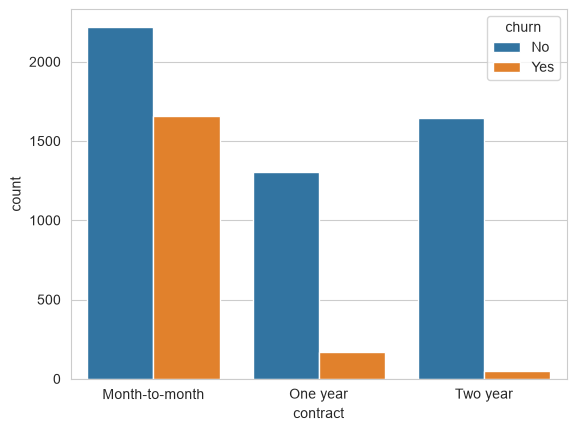

In [20]:
sns.countplot(
    data=df,
    x="contract",
    hue="churn"
)

plt.show()




Customers on **month-to-month contracts exhibit the highest churn levels**, with the number of customers who churned being relatively close to the number who remained. In contrast, customers on **one-year and two-year contracts show significantly lower churn rates**, with the majority remaining active. This suggests that **longer-term contracts are strongly associated with customer retention**, making contract type a potentially important predictor of churn.

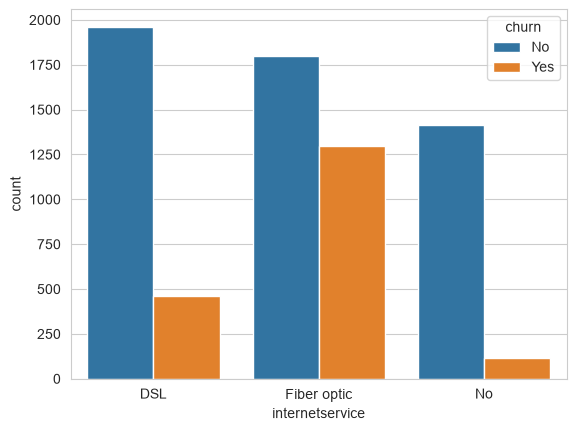

In [21]:
# churn vs internet service type

sns.countplot(
    data=df,
    x="internetservice",
    hue="churn"
)

plt.show()



Customers with **Fiber optic internet service have the highest churn levels**, with a substantial number of customers leaving compared to DSL and customers without internet service. In contrast, **DSL and non-internet customers show much lower churn rates**, suggesting that internet service type, particularly Fiber optic, may be an important factor influencing customer retention.

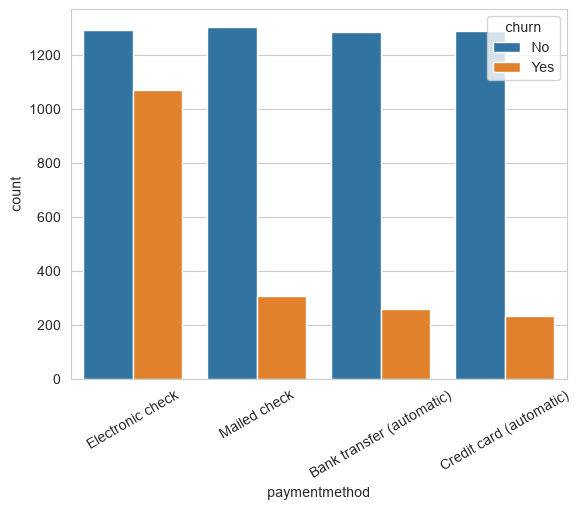

In [22]:
# churn vs payment method
sns.countplot(
    data=df,
    x="paymentmethod",
    hue="churn"
)

plt.xticks(rotation=30)

plt.show()




Customers using electronic checks exhibit noticeably higher churn compared to other payment methods. In contrast, customers using automatic payment methods tend to have lower churn rates.

In [24]:
# churn analysis function
def churn_rate(df, column):

    return round(

        pd.crosstab(
            df[column],
            df["churn"],
            normalize="index"
        ) * 100,

        2

    )
churn_rate(
    df,
    "contract"
)




churn,No,Yes
contract,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


## Correlation Analysis

In [26]:
num_df = df.select_dtypes(
    include=["number"]
)
corr = num_df.corr()

corr



,seniorcitizen,tenure,monthlycharges,totalcharges
seniorcitizen,1.000000,0.016567,0.220173,0.103006
tenure,0.016567,1.000000,0.247900,0.826178
monthlycharges,0.220173,0.247900,1.000000,0.651174
totalcharges,0.103006,0.826178,0.651174,1.000000


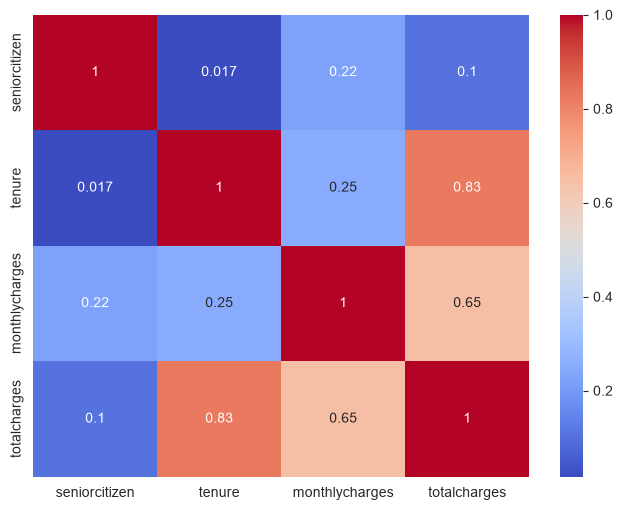

In [27]:
# heatmap of correlation matrix

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.show()




Tenure and Total Charges show a strong positive correlation (0.83), indicating that longer-serving customers accumulate higher total charges. Monthly Charges also have a moderate positive relationship with Total Charges (0.65).

## Key EDA Findings & Business Recommendations

| Key EDA Finding | Business Recommendation |
|----------------|------------------------|
| Churned customers typically have much shorter tenure than retained customers. | Implement onboarding and retention campaigns targeting customers during their first year. |
| Customers with higher monthly charges are more likely to churn. | Review high-priced plans and assess whether customers perceive sufficient value for the cost. |
| Customers who churn generally have lower total charges due to shorter customer lifetimes. | Focus retention efforts on newer customers before they disengage and leave. |
| Month-to-month contracts show significantly higher churn than one-year and two-year contracts. | Encourage customers to migrate to longer-term contracts through discounts or loyalty incentives. |
| Fiber optic customers exhibit higher churn than other internet service groups. | Investigate potential issues related to pricing, service quality, or customer expectations for fiber plans. |
| Customers using electronic checks have noticeably higher churn rates. | Promote automatic payment methods such as bank transfer or credit card auto-pay. |
| The customer base is evenly distributed by gender, suggesting gender is not a strong differentiator. | Prioritize behavioral and service-related factors over demographic characteristics. |
| Most customers do not have dependents, indicating the customer base is primarily individual-focused. | Tailor marketing and retention strategies to individual customer needs and usage patterns. |
| Tenure and Total Charges are strongly correlated (0.83). | Monitor for multicollinearity during modelling and evaluate feature importance before feature selection. |

## Overall Conclusion

- Customer churn is primarily associated with **short tenure**, **month-to-month contracts**, **higher monthly charges**, **fiber optic service**, and **electronic check payments**.
- Retention strategies should focus on **new customers**, **high-cost plans**, and **customers on flexible contract arrangements**.
- Contract structure appears to be one of the strongest business levers for reducing churn.